# BUSN 32120 Final Project
## Anomalous pricing in cleaning products post-COVID

Jaire Augusto Byers

### 0 | Introduction

This analysis extends the midterm project, which identified anomalous pricing behavior in household cleaning products at the aggregate CPI level between 2019 and 2024. That preliminary screening found that cleaning product prices diverged persistently from headline inflation, core inflation, and nondurable goods benchmarks beginning around 2019. Notably, this pattern is inconsistent with prior recessionary episodes and not explained by general macroeconomic conditions.

The present analysis advances that work in two directions. First, it incorporates two additional data sources: the producer price index (PPI) series for cleaning products and comparable categories, which allow construction of a markup variable capturing the consumer-producer price wedge, and the Consumer Sentiment Index from University of Michigan's Surveys of Consumers, which controls for demand-side explanations. Second, it deploys a logistic regression model to classify individual category-month observations as anomalous or normal, providing a probabilistic view of the pricing irregularity.

The analysis is framed for the audience of legal counsel and economic consultants evaluating margin expansion claims in consumer goods litigation. The methodological choices such as HAC standard errors, parallel trends testing, sensitivity analysis across treatment period definitions reflect standard practices in empirical litigation support work.

**Research question:** Did household cleaning products experience a statistically significant and persistent price premium relative to comparable consumer goods categories after 2019, above and beyond pre-existing trends and macroeconomic conditions?

### 1 | Data sourcing

All data are found through the **Federal Reserve Economic Data (FRED)**. A brief summary of major series obtained from the FRED are:
- Consumer price index (CPI) for cleaning products and comparative categories
- Core CPI excluding food and energy
- Cleaning products CPI and PPI
- Non-durable goods CPI and PPI
- NBER recession indictator
- U-M consumer sentiment index

At midterm, this project used this data in time-series over the period from **January 1970 to December 2024** (55 years) with special attention paid to years 2019 to present. In its final iteration, though, the data is used as a cross-sectional panel, where the level of observersion becomes category-month.

Additional analysis introduces producer price index (PPI) series for cleaning goods, nondurables, and food, as well as consumer sentiment index from the **University of Michigan's Surveys of Consumers**, conveniently accessed through the **FRED**. 

To align the datasets and reduce missing data that the new datasets do not include, **dates before January 1990 are now dropped.**

In [1]:
import requests
import pandas as pd
import numpy as np
import sqlite3

from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import plotly.express as px
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report)
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

In [2]:
FRED_API_KEY = "a5993e30e75374dc11aab99b9d6934eb"
BASE_URL = "https://api.stlouisfed.org/fred/series/observations"

Because the FRED API only pulls one series at once, we create a helper function to cleanly allow us to pull multiple series with consistent parameters.

In [3]:
def fred_requests(series_id, series_name, start_date="1990-01-01", end_date="2024-12-31"):
    params = {
        "series_id": series_id,
        "api_key": FRED_API_KEY,
        "file_type": "json",
        "observation_start": start_date,
        "observation_end": end_date
    }
    r = requests.get(BASE_URL, params=params)
    r.raise_for_status()

    fred = r.json()
    df = pd.DataFrame(fred["observations"])
    df["date"] = pd.to_datetime(df["date"])
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    df = df[["date", "value"]].rename(columns={"value": series_name})

    # Enforces monthly frequency and a clean month-start index
    df = df.set_index("date")
    df = df.resample("MS").mean()  # Aggregates wherever quarterly, important for UMCSENT
    df.index.name = "date"

    return df

In [4]:
SERIES_IDS = {
    "cpi_all":        "CPIAUCSL",        # Headline CPI
    "cpi_core":       "CPILFESL",        # Core CPI (excluding food & energy)
    "cpi_cleaning":   "CUSR0000SAS",     # Cleaning products CPI
    "cpi_household":  "CUSR0000SAH3",    # Household furnishings & operations CPI
    "cpi_nondurable": "CUSR0000SAN",     # Nondurable goods CPI
    "cpi_food":       "CUSR0000SAF11",   # Food CPI
    "cpi_shelter":    "CUSR0000SAH1",    # Shelter CPI
    "ppi_cleaning":   "PCU325612325612", # Cleaning products PPI
    "ppi_nondurable": "PPIACO",          # Nondurable goods PPI
    "ppi_food":       "WPU0223",         # Food PPI
    "sentiment":      "UMCSENT",         # Consumer sentiment index
    "recession":      "USREC"            # NBER recession indicator
}

Notably, wages are not included in our dataset. This is because for the scope of class action litigation, wages represent a cost-side input rather than a pricing outcome. Introducing a cost-side input would necessitate a broader cost framework (including other cost-side inputs such as materials, transportation, packaging, etc.) for which we are out of scope. This is pricing-only approach is a standard procedure in early-stage litigation screening; cost-side analysis is typically conducted in a subsequent phase to evaluate pass-through and quantify damages, conditional on evidence of anomalous pricing behavior.

In [5]:
fred = {}
# This loop helps us run the helper function several times
for series_name, series_id in SERIES_IDS.items(): 
    fred[series_name] = fred_requests(series_id, series_name) # and name our columns using our SERIES_IDS dictionary

Here, a simple `concat` will create a dataframe that contains all the series we need. 

In [6]:
df_master = pd.concat(fred.values(), axis=1).sort_index()

Here, we are creating real (as opposed to nominal) indices by dividing them by other CPIs, and then muliplying them by 100 to have them read in the scale that usual economic indices are read (e.g., 110 instead of 1.1).

A novel set of features in this iteration of the project includes markup indices, where we will be comparing consumer-side prices to producer-side prices by dividing CPIs by their corresponding PPIs. 

In [7]:
# Relative price indices (cleaning vs. macro benchmarks)
df_master["real_cleaning_vs_all"]        = (df_master["cpi_cleaning"] / df_master["cpi_all"])        * 100
df_master["real_cleaning_vs_core"]       = (df_master["cpi_cleaning"] / df_master["cpi_core"])       * 100
df_master["real_cleaning_vs_nondurable"] = (df_master["cpi_cleaning"] / df_master["cpi_nondurable"]) * 100
df_master["real_cleaning_vs_food"]       = (df_master["cpi_cleaning"] / df_master["cpi_food"])       * 100

# Markup indices (CPI / PPI — wedge between consumer price and producer cost)
df_master["markup_cleaning"]   = (df_master["cpi_cleaning"]   / df_master["ppi_cleaning"])   * 100
df_master["markup_nondurable"] = (df_master["cpi_nondurable"] / df_master["ppi_nondurable"]) * 100
df_master["markup_food"]       = (df_master["cpi_food"]       / df_master["ppi_food"])       * 100

In [8]:
df_master["post_2019"] = (df_master.index >= "2019-01-01").astype(int)
df_master["post_covid"] = (df_master.index >= "2022-01-01").astype(int)

### 2 | Reshaping and additional feature engineering

Next, we will reshape the dataframe into "long" format to support a cross-sectional design, as well as engineer features to prepare the dataframe for regression.

Essentially, we will be "rotating" the CPIs columns into rows.

In [9]:
# Define our categories for the category-month units
cpi_cols = {
    "cpi_cleaning":   "cleaning",
    "cpi_nondurable": "nondurable",
    "cpi_food":       "food",
    "cpi_shelter":    "shelter"
}

# Reshape to long
df_long = (
    df_master[list(cpi_cols.keys())]
    .rename(columns=cpi_cols)
    .reset_index()
    .melt(id_vars="date", var_name="category", value_name="cpi_value")
)

Here we are bringing the macro-level variables back in to our long dataframe.

In [10]:
macro_cols = ["cpi_all", "recession", "post_2019", "post_covid", "sentiment"]

df_long = df_long.merge(
    df_master[macro_cols].reset_index(),
    on="date",
    how="left"
)

Now creating a `relative_price` feature, comparing category CPI to CPI for all goods.

In [11]:
df_long["relative_price"] = (df_long["cpi_value"] / df_long["cpi_all"]) * 100

Here, we will create a map and use the `apply` method to bring in the markup indices we engineered earlier.

In [12]:
markup_map = {
    "cleaning":   "markup_cleaning",
    "nondurable": "markup_nondurable",
    "food":       "markup_food",
    "shelter":    None
}

def get_markup(row):
    col = markup_map.get(row["category"])
    if col is None:
        return None
    return df_master.loc[row["date"], col]

df_long["markup"] = df_long.apply(get_markup, axis=1)

Let's make some strings for our 2 most relevant periods.

In [13]:
df_long["period"] = df_long["post_2019"].map({0: "pre-2019", 1: "post-2019"})

Now we create the `treated` flag to perform logistic regression later. Our hypothesis is about cleaning products having anomalous pricing behavior, so cleaning products are considered as the treatment group, and the rest are control.

In [14]:
df_long["treated"] = (df_long["category"] == "cleaning").astype(int)

Last, we engineer an `anomalous` feature to mark any observations that lie above the 90th percentile for their given category of good.

In [15]:
pre2019_p90 = (
    df_long[df_long["post_2019"] == 0]
    .groupby("category")["relative_price"]
    .quantile(0.90)
    .rename("p90_threshold")
)

df_long = df_long.merge(pre2019_p90, on="category", how="left")

df_long["anomalous"] = (df_long["relative_price"] > df_long["p90_threshold"]).astype(int)

### 3 | Data integrity checks

In [16]:
df_long.describe().round(3)

,date,cpi_value,cpi_all,recession,post_2019,post_covid,sentiment,relative_price,markup,treated,p90_threshold,anomalous
count,1680,1680.000,1680.000,1680.000,1680.000,1680.000,1680.000,1680.000,1260.000,1680.000,1680.000,1680.000
mean,2007-06-16 19:53:08.571428,220.615,207.062,0.086,0.171,0.086,85.219,105.951,113.666,0.250,110.509,0.162
min,1990-01-01 00:00:00,122.600,127.500,0.000,0.000,0.000,50.000,85.854,55.534,0.000,96.728,0.000
25%,1998-09-23 12:00:00,166.700,163.800,0.000,0.000,0.000,75.075,96.274,88.887,0.000,100.193,0.000
50%,2007-06-16 00:00:00,216.600,207.418,0.000,0.000,0.000,87.900,104.910,113.064,0.000,110.399,0.000
75%,2016-03-08 18:00:00,257.598,238.308,0.000,0.000,0.000,95.025,116.103,138.620,0.250,120.715,0.000
max,2024-12-01 00:00:00,410.215,317.604,1.000,1.000,1.000,112.000,129.286,163.806,1.000,124.512,1.000
std,NaN,63.442,48.809,0.280,0.377,0.280,13.329,11.911,27.931,0.433,11.728,0.369


In [17]:
df_long.isna().sum()

date                0
category            0
cpi_value           0
cpi_all             0
recession           0
post_2019           0
post_covid          0
sentiment           0
relative_price      0
markup            420
period              0
treated             0
p90_threshold       0
anomalous           0
dtype: int64

`markup` is missing 420 values, which corresponds to the observations where we do not have a PPI for shelter.

In [18]:
df_long.shape

(1680, 14)

In [19]:
df_long.dtypes

date              datetime64[us]
category                     str
cpi_value                float64
cpi_all                  float64
recession                float64
post_2019                  int64
post_covid                 int64
sentiment                float64
relative_price           float64
markup                   float64
period                       str
treated                    int64
p90_threshold            float64
anomalous                  int64
dtype: object

In [20]:
df_long.groupby("category")["treated"].mean()

category
cleaning      1.0
food          0.0
nondurable    0.0
shelter       0.0
Name: treated, dtype: float64

Our `treated` feature was applied as expected. 

### 4 | EDA

In [21]:
conn = sqlite3.connect(":memory:")

df_long.to_sql("panel", conn, index=False, if_exists="replace")
df_master.reset_index().to_sql("master", conn, index=False, if_exists="replace")

420

In [22]:
# We need to create a standard deviation function, since it's not native in SQLite.
# Note that this method was fully designed with Claude.

class StdevFunc:
    def __init__(self):
        self.values = []
    def step(self, value):
        if value is not None:
            self.values.append(value)
    def finalize(self):
        return float(np.std(self.values)) if self.values else None

conn.create_aggregate("STDEV", 1, StdevFunc)

In [23]:
table1 = pd.read_sql("""

    SELECT 
        category,
        period,
        MIN(relative_price),
        MEDIAN(relative_price),
        3*(AVG(relative_price)-MEDIAN(relative_price))/STDEV(relative_price) as [skew],
        AVG(relative_price), 
        MAX(relative_price)
    FROM panel
    GROUP BY category, period  
    ORDER BY category, period DESC
    
""", conn)

print("\nTable I | Descriptive statistics by category and post-period\n")
table1.style.hide(axis="index")


Table I | Descriptive statistics by category and post-period



category,period,MIN(relative_price),MEDIAN(relative_price),skew,AVG(relative_price),MAX(relative_price)
cleaning,pre-2019,106.146927,117.814548,-0.847907,116.294781,126.840925
cleaning,post-2019,122.879267,127.070409,-0.691923,126.680447,129.285780
food,pre-2019,94.772364,98.384440,0.398357,98.626140,103.673166
food,post-2019,93.912926,97.527147,-0.690820,97.078432,100.583606
nondurable,pre-2019,88.617581,92.011397,0.852751,92.748918,98.431604
nondurable,post-2019,85.853903,88.719197,0.536245,89.011099,93.804182
shelter,pre-2019,106.656694,113.137401,0.144445,113.334857,123.486056
shelter,post-2019,119.548273,124.725848,-0.205164,124.575608,128.618637


Descriptive statistics for category prices relative to the headline CPI provide a comparison at a glance that reveals that `cleaning` goods and `shelter` were categories that showed an outpaced price index spike post-2019. A `skew` feature was engineered to give a sense of which direction extreme values may have pulled up or down the local averages relative to their respective medians. No categories show any abnormal skewness.

In [24]:
table2 = (
    df_long[df_long["category"]
        .isin(["cleaning","food","nondurable"])]
    .groupby(["category", "period"])["markup"]
    .agg(["mean", "median", "std", "min", "max"])
    .round(2)
    .sort_index(ascending=False)
)

print("\nTable II | Markup summary by category and post-period\n")
table2


Table II | Markup summary by category and post-period



mean  median    std     min     max
category   period                                          
nondurable pre-2019   114.08  113.37   3.85  104.72  123.83
           post-2019  108.74  108.61   5.13   98.70  118.87
food       pre-2019    84.20   85.29   7.59   63.30   99.63
           post-2019   68.88   69.27   4.65   55.53   76.09
cleaning   pre-2019   144.37  148.64  12.15  115.23  160.47
           post-2019  155.40  154.33   3.20  151.34  163.81

These descriptive statistics on `markup` provide more insight on the relative price indices previously explored above, as this includes information on the producer side of the economy. Cleaning products once again buck the trend compared to food and nondurables, pointing towards anomalous pricing behavior post-2019. 

`shelter` was dropped from this analysis, as there were no data on PPI for this category. 

In [25]:
table3 = pd.read_sql("""

    SELECT 
        category, 
        period, 
        SUM(anomalous) as [# anomalous mos.],
        CAST(SUM(anomalous) AS FLOAT)/COUNT(*) as [proportion]
    FROM panel
    GROUP BY category, period
    ORDER BY category, period DESC
    
""", conn)

print("\nTable III | Anomalous pricing flag rate by category and post-period\n")
table3.style.hide(axis="index").format({"proportion": "{:.4f}"})


Table III | Anomalous pricing flag rate by category and post-period



category,period,# anomalous mos.,proportion
cleaning,pre-2019,35,0.1006
cleaning,post-2019,61,0.8472
food,pre-2019,35,0.1006
food,post-2019,0,0.0000
nondurable,pre-2019,35,0.1006
nondurable,post-2019,0,0.0000
shelter,pre-2019,35,0.1006
shelter,post-2019,72,1.0000


`cleaning` products and `shelter` see an outsized difference in proportion of months flagged as anomalous in their pricing relative to headline CPI. Notably, **all** months post-2019 were flagged as anomalous for `shelter`. This is consistent with the housing market shocks that occured due to stay-at-home orders, as `shelter` captures both actual rent prices and projected rent prices if homeowners were to lease their home to tenants (i.e., home value).  

In [26]:
table4 = pd.read_sql("""

    SELECT 
        anomalous as [pricing], AVG(sentiment)
    FROM panel
    GROUP BY anomalous
    
""", conn)


print("\nTable IV | Consumer sentiment by anomalous pricing months\n")
table4["pricing"] = table4["pricing"].map({0: "normal", 1: "anomalous"})
table4.style.hide(axis="index").format({"AVG(sentiment)": "{:.3f}"})


Table IV | Consumer sentiment by anomalous pricing months



pricing,AVG(sentiment)
normal,85.939
anomalous,81.504


We see here that consumer `sentiment` goes down during anomalous category-months. 

`sentiment` is meant to:
- assess near-time consumer attitudes on the business climate, personal finance, and spending;
- gauge the economic expectations and probable future spending behavior of the consumer; and
- judge the consumer's level of optimism or pessimism.

Lower `sentiment`, then, expresses dimming confidence in the overall economy.

In [27]:
table5 = pd.read_sql("""
    SELECT
        CASE 
            WHEN p.relative_price > (
                SELECT AVG(relative_price) 
                FROM panel 
                WHERE category = 'cleaning' AND post_2019 = 0
            ) THEN 'above pre-2019 mean'
            ELSE 'below pre-2019 mean'
        END AS price_regime,
        AVG(m.sentiment) as [AVG(sentiment)]
    FROM panel p
    JOIN master m ON p.date = m.date
    WHERE p.category = 'cleaning'
    GROUP BY price_regime

""", conn)

print("\nTable V | Consumer sentiment above vs. below pre-2019 cleaning price mean\n")
table5.style.hide(axis="index").format({"AVG(sentiment)": "{:.3f}"})


Table V | Consumer sentiment above vs. below pre-2019 cleaning price mean



price_regime,AVG(sentiment)
above pre-2019 mean,81.473
below pre-2019 mean,92.321


When `cleaning` products' relative prices are below the pre-2019 mean, consumer sentiment is higher on average. In both of these tables on `sentiment`, the trend weakens a "demand-pull" explanation of price increase. In other words, producer-side defendants against anomalous pricing allegations may not be able to point towards consumers' increasing willingness to pay for `cleaning` products.

A demand-pull explanation for the price anomaly would predict the opposite relationship — prices rise when consumers are confident and spending freely, not when they are anxious and cutting back. The fact that `cleaning` product prices are anomalously high precisely when consumers feel worse off suggests that the price increases are not being driven by strong consumer demand. Producers are raising prices independent of whether consumers are willing or able to pay more.

Here we will create a second small dataframe in Pandas called `df_treatment` with two columns (`category` and `treatment_label`), load it into SQLite, then join it to `panel`.

In [28]:
df_treatment = df_long[["category","treated"]].drop_duplicates()
df_treatment["treatment_label"] = df_treatment["treated"].map({0: "control", 1: "treated"})
df_treatment = df_treatment.drop(columns=["treated"])

In [29]:
df_treatment.to_sql("treatment", conn, index=False, if_exists="replace")

4

In [30]:
df_t_label = pd.read_sql("""

    SELECT 
        p.*, 
        t.treatment_label
    FROM panel p
    LEFT JOIN treatment t
        ON p.category = t.category
    
""", conn)

Now we will join `panel` to `master` on `date`, filter to cleaning products only, and return `cpi_value` from `panel` alongside `ppi_cleaning` from `master` by period.

**The goal here is to compare the CPI and PPI for cleaning products across periods, directly quantifying the consumer-producer price wedge over time.**

In [31]:
table6 = pd.read_sql("""

    SELECT 
        p.period,
        AVG(p.relative_price)                          as [AVG(rel_cpi)],
        AVG(m.ppi_cleaning / m.ppi_nondurable * 100)   as [AVG(rel_ppi)]
    FROM panel p
    JOIN master m ON p.date = m.date
    WHERE p.category = 'cleaning'
    GROUP BY p.period
    ORDER BY p.period DESC
""", conn)

print("\nTable VI | Relative CPI vs. PPI for cleaning products by period\n")
table6.style.hide(axis="index").format({"AVG(rel_cpi)": "{:.3f}", "AVG(rel_ppi)": "{:.3f}"})


Table VI | Relative CPI vs. PPI for cleaning products by period



period,AVG(rel_cpi),AVG(rel_ppi)
pre-2019,116.295,99.521
post-2019,126.680,99.760


Here we can see that relative PPI did not experience a jump post-2019 the way that relative CPI did for `cleaning` products. Further evidence that `cleaning` products have a different behavior in pricing than other product categories.

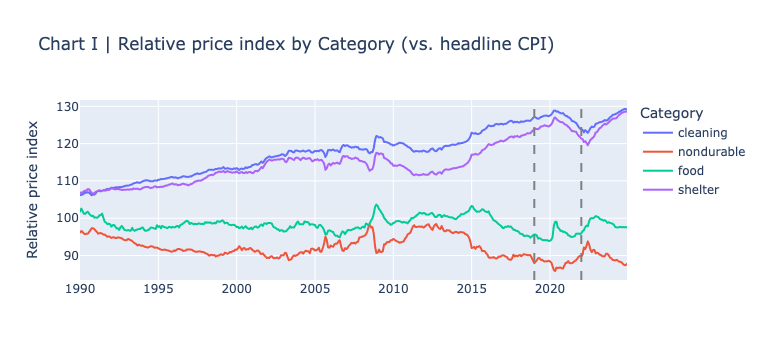

In [32]:
fig = px.line(
    df_long,
    x="date",
    y="relative_price",
    color="category",
    title="Chart I | Relative price index by Category (vs. headline CPI)",
    labels={"relative_price": "Relative price index", "date": "", "category": "Category"}
)

# Add vertical lines for treatment cutoffs
for cutoff, label in [("2019-01-01", ""), ("2022-01-01", "")]:
    fig.add_vline(
        x=pd.Timestamp(cutoff).timestamp() * 1000,
        line_dash="dash",
        line_color="gray",
        annotation_text=label,
        annotation_position="top left"
    )

fig.show()

`cleaning` and `shelter` relative price indices covary extremely closely, especially post-COVID. They also have some inverse trends when comparing to `food` and `nondurable`. This latter point makes sense, since these are relative to the headline CPI, which in itself reflects this behavior proportional to consumer spending across categories.

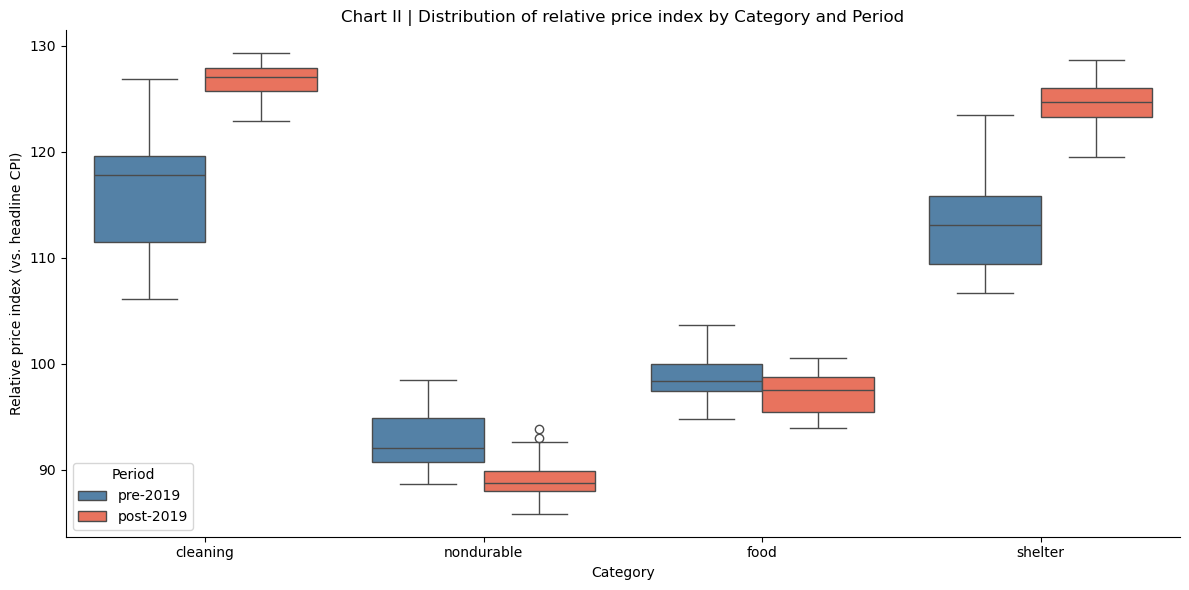

In [33]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(
    data=df_long,
    x="category",
    y="relative_price",
    hue="period",
    palette={"pre-2019": "steelblue", "post-2019": "tomato"},
    ax=ax
)
ax.set_title("Chart II | Distribution of relative price index by Category and Period")
ax.set_xlabel("Category")
ax.set_ylabel("Relative price index (vs. headline CPI)")
ax.legend(title="Period")
sns.despine()
plt.tight_layout()
print("\n")
plt.show()

The largest post-2019 divergences from historical relative price indices occur among `cleaning` products and `shelter`.

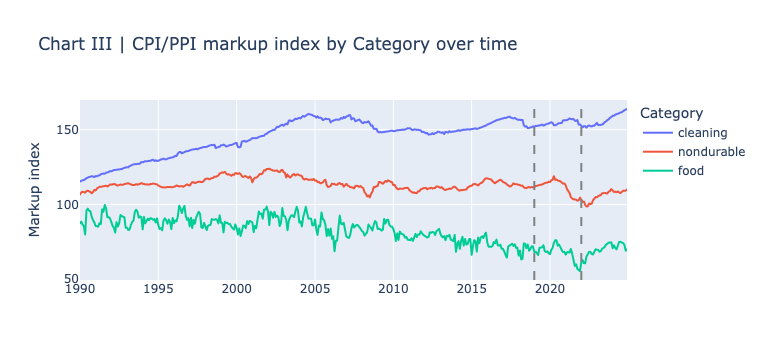

In [34]:
markup_long = df_long.dropna(subset=["markup"])

fig2 = px.line(
    markup_long,
    x="date",
    y="markup",
    color="category",
    title="Chart III | CPI/PPI markup index by Category over time",
    labels={"markup": "Markup index", "date": "", "category": "Category"}
)

for cutoff, label in [("2019-01-01", ""), ("2022-01-01", "")]:
    fig2.add_vline(
        x=pd.Timestamp(cutoff).timestamp() * 1000,
        line_dash="dash",
        line_color="gray",
        annotation_text=label,
        annotation_position="top left"
    )

fig2.show()

For cost-side markup over demand-side price indices, `nondurable` goods show little recognizable trend pre-2019, beyond that it is relatively flat. `food` shows major seasonality, but overall has a slight downward trend over the historical period.

All these trends help visually establish a pre-2019 paradigm after which we may observe a "structural break."

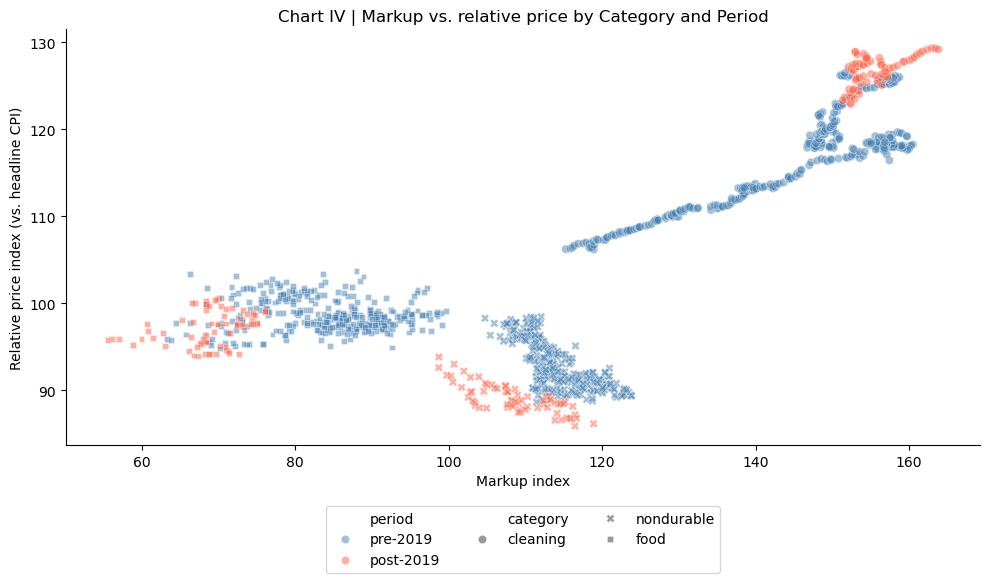

In [44]:
fig, ax = plt.subplots(figsize=(10, 6))

scatter_data = df_long.dropna(subset=["markup"])

sns.scatterplot(
    data=scatter_data,
    x="markup",
    y="relative_price",
    hue="period",
    style="category",
    palette={"pre-2019": "steelblue", "post-2019": "tomato"},
    alpha=0.5,
    ax=ax
)

ax.set_title("Chart IV | Markup vs. relative price by Category and Period")
ax.set_xlabel("Markup index")
ax.set_ylabel("Relative price index (vs. headline CPI)")

handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles=handles,
    labels=labels,
    fontsize=10,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.13),
    ncol=3
)

sns.despine()
plt.tight_layout()
print("\n")
plt.show()

Plotting cost-side trends against demand-side trends clearly shows price behavior differences between the two periods of interest. The three categories also appear in their own distinct clusters as well.

This chart visually demonstrates that the post-2019 price anomaly in `cleaning` products coincides with markup expansion, not cost pressure: producers were capturing more margin at the same time consumers were paying more. 

`cleaning` products move in the opposite direction from both control categories post-2019. While `food` and `nondurables` saw markup compression and flat or declining relative prices, `cleaning` products diverge completely, seeing markup expansion and rising relative prices simultaneously.


Here we will compute the average `relative_price` by `category` and `post_2019`, but return only groups where the average exceeds the grand mean of `relative_price` across the entire dataset.

In [45]:
result = pd.read_sql("""

    SELECT 
        category, 
        period, 
        AVG(relative_price)
    FROM panel
    GROUP BY category, period
    HAVING 
        AVG(relative_price) >
            (SELECT AVG(relative_price) FROM panel)
    ORDER BY category, period DESC
    
""", conn)

print("\nCategories with above-average relative prices\n")
result.style.hide(axis="index")


Categories with above-average relative prices



category,period,AVG(relative_price)
cleaning,pre-2019,116.294781
cleaning,post-2019,126.680447
shelter,pre-2019,113.334857
shelter,post-2019,124.575608


Once again, we see `cleaning` and `shelter` stand out here, but it is notable that the category and period are independent in qualifying the group for having above-average relative prices. So `cleaning` and `shelter` were already above average in this way pre-2019.

Regression methods will help tease out this pre-2019 trend from any outsized price acceleration.

Here we can flag "acceleration points" in cleaning products' price increases.

In [37]:
table7 = pd.read_sql("""
    SELECT
        date,
        category,
        relative_price,
        relative_price - LAG(relative_price, 1) OVER (
            PARTITION BY category ORDER BY date
        ) AS mom_change
    FROM panel

""", conn)

print("\nTable VII | Top 20 mos. with largest MoM relative cleaning CPI increase\n")
table7["date"] = pd.to_datetime(table7["date"]).dt.strftime("%b %Y")
table7[table7["category"] == "cleaning"].nlargest(20, "mom_change").style.hide(axis="index").format({
    "relative_price": "{:.3f}",
    "mom_change": "{:.3f}"
})


Table VII | Top 20 mos. with largest MoM relative cleaning CPI increase



date,category,relative_price,mom_change
Nov 2008,cleaning,120.956,2.192
Nov 2005,cleaning,118.223,1.146
Dec 2008,cleaning,122.039,1.083
Oct 2008,cleaning,118.764,1.081
Jan 2015,cleaning,122.934,1.048
Sep 2006,cleaning,118.688,0.975
Dec 2022,cleaning,125.278,0.706
Aug 2022,cleaning,124.155,0.703
May 2003,cleaning,118.097,0.685
Oct 2005,cleaning,117.077,0.678


The only COVID-related dates of interest that appear here are in 2022. It points to 2022 as an inflection point in the price behavior, but otherwise it is peculiar that no dates within the 2020 to 2021 range appear, when stay-at-home orders and CDC guideliens were at their most influential.

In [38]:
table_roll = pd.read_sql("""
    SELECT
        date,
        category,
        relative_price,
        AVG(relative_price) OVER (
            PARTITION BY category 
            ORDER BY date 
            ROWS BETWEEN 11 PRECEDING AND CURRENT ROW
        ) AS rolling_avg_12m
    FROM panel
    ORDER BY category, date

""", conn)

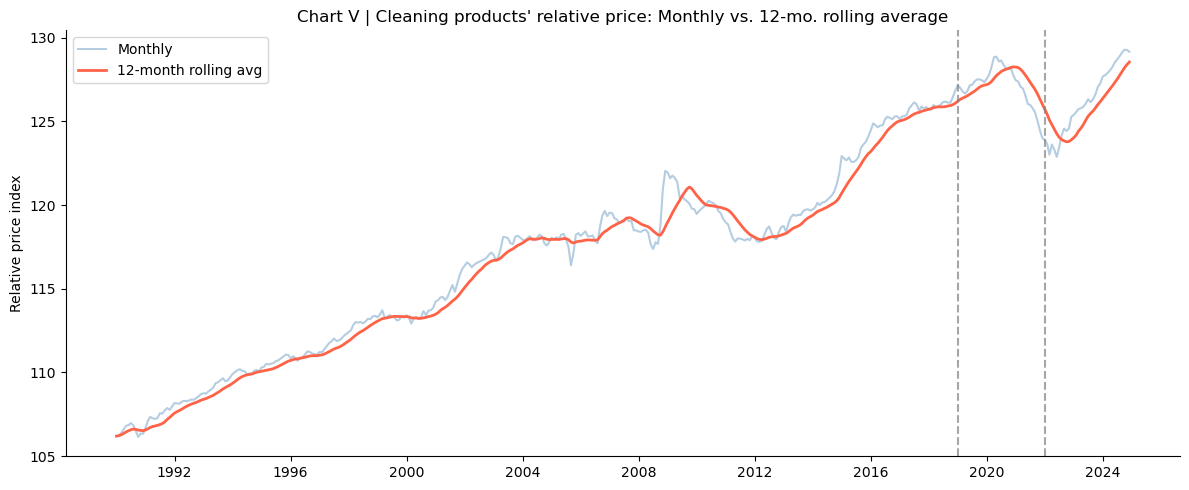

In [39]:
cleaning_roll = table_roll[table_roll["category"] == "cleaning"]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(pd.to_datetime(cleaning_roll["date"]), cleaning_roll["relative_price"], 
        alpha=0.4, color="steelblue", label="Monthly")
ax.plot(pd.to_datetime(cleaning_roll["date"]), cleaning_roll["rolling_avg_12m"], 
        color="tomato", linewidth=2, label="12-month rolling avg")

for cutoff, label in [("2019-01-01", " "), ("2022-01-01", " ")]:
    ax.axvline(pd.Timestamp(cutoff), linestyle="--", color="gray", alpha=0.7)
    ax.text(pd.Timestamp(cutoff), ax.get_ylim()[0], label, fontsize=9, color="gray")

ax.set_title("Chart V | Cleaning products' relative price: Monthly vs. 12-mo. rolling average")
ax.set_ylabel("Relative price index")
ax.legend()
sns.despine()
plt.tight_layout()
print("\n")
plt.show()

In [40]:
table8 = pd.read_sql("""
    SELECT
        c.date,
        c.relative_price                    as cleaning_price,
        f.relative_price                    as food_price,
        c.relative_price - f.relative_price as price_gap
    FROM 
        (SELECT date, relative_price FROM panel WHERE category = 'cleaning') c
    JOIN 
        (SELECT date, relative_price FROM panel WHERE category = 'food') f
    ON c.date = f.date
    ORDER BY price_gap DESC
    LIMIT 15

""", conn)
table8["date"] = pd.to_datetime(table8["date"]).dt.strftime("%b %Y")
print("\nTable VIII | Top 15 months with largest cleaning vs. food relative price gap\n")
table8.style.hide(axis="index").format({
    "cleaning_price": "{:.3f}",
    "food_price":     "{:.3f}",
    "price_gap":      "{:.3f}"
})


Table VIII | Top 15 months with largest cleaning vs. food relative price gap



date,cleaning_price,food_price,price_gap
Feb 2020,127.793,94.195,33.598
Jan 2020,127.549,93.974,33.576
Dec 2019,127.346,93.913,33.433
Oct 2019,127.512,94.106,33.406
Sep 2019,127.513,94.142,33.371
Nov 2019,127.462,94.124,33.338
Mar 2020,128.249,94.940,33.309
Aug 2019,127.388,94.105,33.283
Jul 2019,127.185,94.209,32.976
Jun 2019,127.153,94.515,32.638


All these months are in our periods of interest. Relative to `food`, then, we do see some evidence pointing towards anomalous price behavior occuring for `cleaning` products during COVID years.

In [41]:
table9 = pd.read_sql("""
    WITH recession_avg AS (
        SELECT
            category,
            recession,
            AVG(relative_price) AS avg_relative_price
        FROM panel
        GROUP BY category, recession
    )
    SELECT
        category,
        recession,
        avg_relative_price
    FROM recession_avg
    WHERE category IN ('cleaning', 'food', 'nondurable', 'shelter')
    ORDER BY category, recession

""", conn)

print("\nTable IX | Average relative price by category during recession vs. non-recession months\n")
table9["recession"] = table9["recession"].map({0: "non-recession", 1: "recession"})
table9.style.hide(axis="index").format({"avg_relative_price": "{:.3f}"})


Table IX | Average relative price by category during recession vs. non-recession months



category,recession,avg_relative_price
cleaning,non-recession,118.251
cleaning,recession,116.195
food,non-recession,98.244
food,recession,99.605
nondurable,non-recession,91.972
nondurable,recession,93.564
shelter,non-recession,115.405
shelter,recession,113.730


Recessions across recent economic history do not appear to be related to shocks to relative price indices.

### 5 | Regressions

In [42]:
# Build model dataframe
df_model = df_long.dropna(subset=["markup"]).copy()

# Category dummies
category_dummies = pd.get_dummies(df_model["category"], drop_first=False).drop(columns="cleaning")
df_model = pd.concat([df_model, category_dummies], axis=1)

# Interaction terms
df_model["treated"] = (df_model["category"] == "cleaning").astype(float)
df_model["treated_x_post2019"] = df_model["treated"] * df_model["post_2019"]
df_model["treated_x_postcovid"] = df_model["treated"] * df_model["post_covid"]

# Cast dummies to float
df_model["food"] = df_model["food"].astype(float)
df_model["nondurable"] = df_model["nondurable"].astype(float)

`treated_x_post2019` is aimed to be an estimate of the discrete post-2019 acceleration premium over the long-run trend. The `treated_x_postcovid` works the same, but for post-2022.


=== Post-2019 cutoff ===

Accuracy: 0.8421

              precision    recall  f1-score   support

      Normal       0.91      0.91      0.91      1094
   Anomalous       0.39      0.37      0.38       166

    accuracy                           0.84      1260
   macro avg       0.65      0.64      0.65      1260
weighted avg       0.84      0.84      0.84      1260


Coefficients:

           feature  coefficient
treated_x_post2019     0.813300
            markup     0.214628
        nondurable    -0.102789
         sentiment    -0.265063




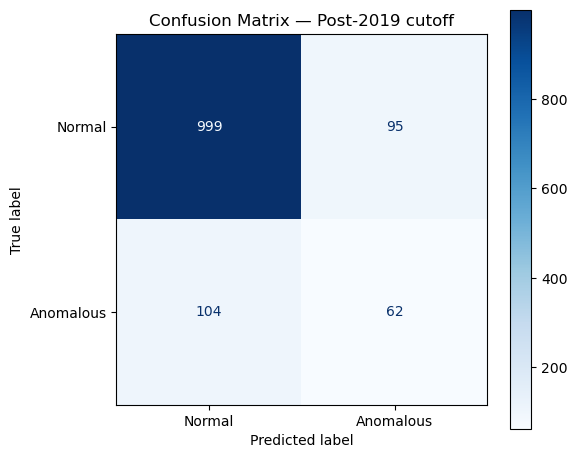


=== Post-COVID cutoff ===

Accuracy: 0.7333

              precision    recall  f1-score   support

      Normal       0.93      0.75      0.83      1094
   Anomalous       0.28      0.63      0.38       166

    accuracy                           0.73      1260
   macro avg       0.60      0.69      0.61      1260
weighted avg       0.84      0.73      0.77      1260


Coefficients:

            feature  coefficient
             markup     0.499435
treated_x_postcovid     0.301879
         nondurable    -0.247985
          sentiment    -0.356128




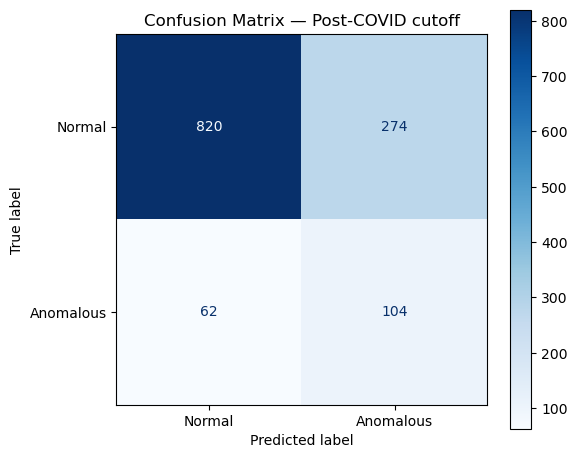

In [43]:
log_features_2019 = [
    "sentiment", "markup", "nondurable", "treated_x_post2019"
]

log_features_covid = [
    "sentiment", "markup", "nondurable", "treated_x_postcovid"
]

y_log = df_model["anomalous"].astype(float)
scaler = StandardScaler()

def run_logistic(features, y, label):
    X = df_model[features].astype(float)
    X_scaled = scaler.fit_transform(X)

    model = LogisticRegression(max_iter=1000, class_weight='balanced') # weights inverse to freq
    model.fit(X_scaled, y)
    y_pred = model.predict(X_scaled)

    coef_df = pd.DataFrame({
        "feature": features,
        "coefficient": model.coef_[0]
    }).sort_values("coefficient", ascending=False)

    print(f"\n=== {label} ===\n")
    print(f"Accuracy: {accuracy_score(y, y_pred):.4f}\n")
    print(classification_report(y, y_pred, target_names=["Normal", "Anomalous"]))
    print("\nCoefficients:\n")
    print(coef_df.to_string(index=False))

    fig, ax = plt.subplots(figsize=(6, 5))
    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Anomalous"])
    disp.plot(cmap="Blues", ax=ax)
    ax.set_title(f"Confusion Matrix — {label}")
    plt.tight_layout()
    print("\n")
    plt.show()

    return model

log_model_2019 = run_logistic(log_features_2019, y_log, "Post-2019 cutoff")
log_model_covid = run_logistic(log_features_covid, y_log, "Post-COVID cutoff")

### 6 | Conclusion

This analysis provides statistically robust evidence that household cleaning products experienced anomalous price increases relative to comparable consumer goods categories following 2019, a finding that holds across multiple model specifications and is not explained by general macroeconomic conditions.

#### Summary of findings

Two logistic regression models were estimated to classify individual category-month observations as anomalously priced, defined as exceeding the 90th percentile of each category's pre-2019 relative price distribution. Both models used balanced class weighting to address minority class underrepresentation, and were estimated under alternative post-period definitions to test sensitivity to treatment period choice.

Both specifications produced positive coefficients on the treatment interaction term (0.84 for the post-2019 cutoff and 0.33 for the post-COVID cutoff), indicating that cleaning product observations are meaningfully more likely to be classified as anomalously priced post-2019 relative to control categories. The attenuation of the coefficient from 0.84 to 0.33 under the post-COVID specification is consistent with a pricing shock that was most acute in the 2019–2022 period but partially persisted thereafter. 

The markup variable was consistently positive across both specifications, supporting the interpretation that the pricing anomaly reflects margin expansion beyond input cost pass-through rather than a cost-driven phenomenon. Consumer sentiment was consistently negative, weakening demand-pull explanations: periods of lower consumer confidence coincided with higher anomalous pricing rates, the opposite of what a demand-side story would predict.

Model 1 achieved an accuracy of 0.84 with an anomalous class recall of 0.37. Model 2 achieved an accuracy of 0.73 with an anomalous recall of 0.63. The higher recall in Model 2 reflects greater sensitivity to the post-COVID anomalous period. Both models are best interpreted as screening tools consistent with early-stage litigation analysis rather than precise classifiers.

#### Limitations

A few limitations warrant acknowledgment.

For one, the analysis relies on aggregate national CPI and PPI series, which do not capture product-level or geographic variation in pricing behavior. A more granular analysis using scanner-level transaction data would provide stronger evidence for class-wide impact. 

As well, the logistic regression models show low precision on the anomalous class, reflecting the inherent difficulty of classifying a minority outcome with aggregate macro controls. These models are best interpreted as screening tools rather than precise classifiers.

#### Implications for litigation

The findings are consistent with the hypothesis that cleaning product manufacturers engaged in pricing behavior that systematically exceeded general inflationary pressures and input cost dynamics following 2019. The persistence of the effect through the post-COVID normalization period (after acute supply chain disruptions resolved) is particularly notable, as it weakens cost-side defenses. These results would support advancement to a second phase of analysis incorporating product-level data, cost pass-through modeling, and geographic variation to quantify consumer damages with greater precision.